In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/fitness_level.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


<Axes: >

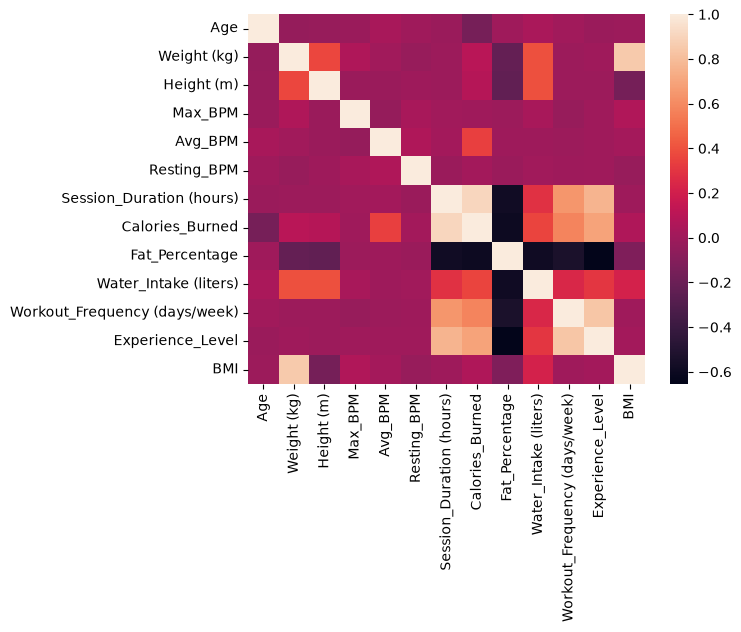

In [3]:
df_numerical = df.select_dtypes(include='number')
df_numerical.head()

corr = df_numerical.corr()
sns.heatmap(corr)

In [4]:
filtered_df = pd.DataFrame(data={
    'age': df['Age'],
    'gender': df['Gender'].map({'Male': 'M', 'Female': 'F'}),
    'weight_kg': df['Weight (kg)'],
    'height_cm': df['Height (m)'] * 100,
    'max_bpm': df['Max_BPM'],
    'avg_bpm': df['Avg_BPM'],
    'resting_bpm': df['Resting_BPM'],
    'water_intake_liter_daily': df['Water_Intake (liters)'],
    'workout_frequency_days_per_week': df['Workout_Frequency (days/week)'],
    'session_duration_hours': df['Session_Duration (hours)'],
    'bmi': df['BMI'],
    'experience_level': df['Experience_Level'],
})

filtered_df.head()

,age,gender,weight_kg,height_cm,max_bpm,avg_bpm,resting_bpm,water_intake_liter_daily,workout_frequency_days_per_week,session_duration_hours,bmi,experience_level
0,56,M,88.3,171.0,180,157,60,3.5,4,1.69,30.20,3
1,46,F,74.9,153.0,179,151,66,2.1,4,1.30,32.00,2
2,32,F,68.1,166.0,167,122,54,2.3,4,1.11,24.71,2
3,25,M,53.2,170.0,190,164,56,2.1,3,0.59,18.41,1
4,38,M,46.1,179.0,188,158,68,2.8,3,0.64,14.39,1


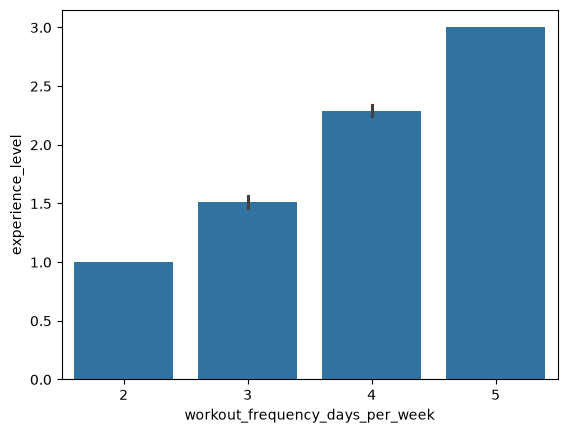

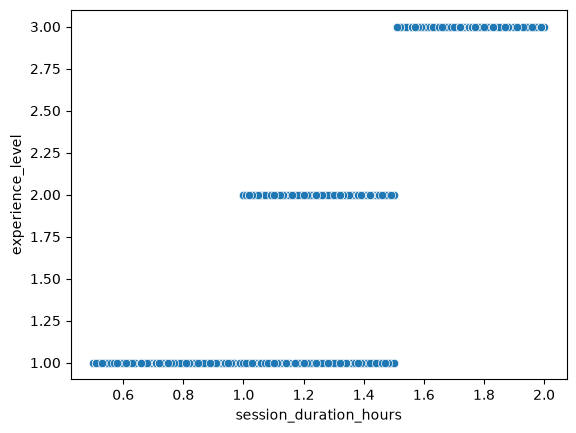

In [5]:
sns.barplot(filtered_df, x='workout_frequency_days_per_week', y='experience_level')
plt.show()

sns.scatterplot(filtered_df, x='session_duration_hours', y='experience_level')
plt.show()

In [6]:
filtered_df['experience_level'].value_counts()

experience_level
2    406
1    376
3    191
Name: count, dtype: int64

In [7]:
filtered_df.to_csv("../datasets/cleaned/fitness_level.csv")

### Training Data

#### Step 1: Import Library & Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Load dataset fitness_level
df_fitness = pd.read_csv('../datasets/cleaned/fitness_level.csv', index_col=0)
df_fitness.head()

,age,gender,weight_kg,height_cm,max_bpm,avg_bpm,resting_bpm,water_intake_liter_daily,workout_frequency_days_per_week,session_duration_hours,bmi,experience_level
0,56,M,88.3,171.0,180,157,60,3.5,4,1.69,30.20,3
1,46,F,74.9,153.0,179,151,66,2.1,4,1.30,32.00,2
2,32,F,68.1,166.0,167,122,54,2.3,4,1.11,24.71,2
3,25,M,53.2,170.0,190,164,56,2.1,3,0.59,18.41,1
4,38,M,46.1,179.0,188,158,68,2.8,3,0.64,14.39,1


#### Step 2: Preprocessing & Encoding Fitur

In [9]:
# Convert gender (M/F) ke angka (1/0)
df_fitness['gender'] = df_fitness['gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

# Pastikan tidak ada missing values
df_fitness = df_fitness.dropna()


#### Step 3: Memisahkan Fitur (X) dan Target Label (y)

In [10]:
# Kolom fitur
X = df_fitness.drop(columns=['experience_level', 'id', 'Unnamed: 0'], errors='ignore')

# Label Target (experience_level)
y = df_fitness['experience_level']

print("Fitur yang digunakan:", list(X.columns))

Fitur yang digunakan: ['age', 'gender', 'weight_kg', 'height_cm', 'max_bpm', 'avg_bpm', 'resting_bpm', 'water_intake_liter_daily', 'workout_frequency_days_per_week', 'session_duration_hours', 'bmi']


#### Step 4: Split Data (Train-Test Split 80:20)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Train: {len(X_train)} | Data Test: {len(X_test)}")


Jumlah Data Train: 778 | Data Test: 195


#### Step 4B: Feature Scaling (StandardScaler untuk SVM & KNN)

In [12]:
# Inisialisasi StandardScaler
scaler = StandardScaler()
print(X_train)

# Fit dan transform pada data train, transform pada data test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Fitur berhasil diskalakan dengan StandardScaler.")

     age  gender  weight_kg  height_cm  max_bpm  avg_bpm  resting_bpm  \
87    41       0       55.0      155.0      175      169           65   
729   59       1       96.7      171.0      183      150           62   
493   53       0       47.8      176.0      164      149           74   
490   41       0       77.6      176.0      162      161           71   
114   52       1       82.4      172.0      166      137           53   
..   ...     ...        ...        ...      ...      ...          ...   
434   53       0       68.0      170.0      181      139           57   
182   34       0       56.2      177.0      192      138           59   
427   53       1      105.1      184.0      176      130           62   
77    58       0       66.1      175.0      169      128           57   
318   38       1       61.3      197.0      177      146           51   

     water_intake_liter_daily  workout_frequency_days_per_week  \
87                        2.0                            

#### Step 5: Training Model Random Forest Classifier

In [13]:
# Inisialisasi RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Fitting Model
rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih!")


Model Random Forest berhasil dilatih!


#### Step 6: Evaluasi Model (Akurasi & Confusion Matrix)

Akurasi Model Random Forest: 90.26%

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.89      0.85      0.87        75
           2       0.87      0.90      0.89        82
           3       1.00      1.00      1.00        38

    accuracy                           0.90       195
   macro avg       0.92      0.92      0.92       195
weighted avg       0.90      0.90      0.90       195



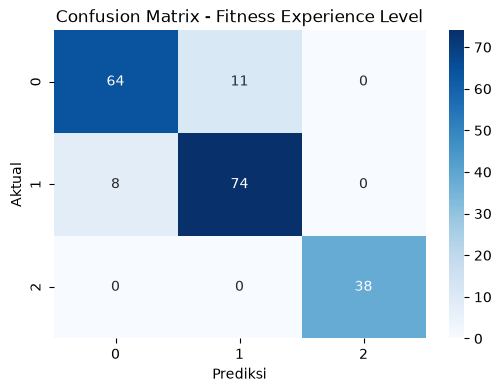

In [14]:
# Prediksi data test
y_pred = rf_model.predict(X_test)

# Hitung Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest: {acc * 100:.2f}%\n")

# Report Klasifikasi
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Fitness Experience Level')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


#### Step 7: Analisis Fitur Paling Berpengaruh (Feature Importance)

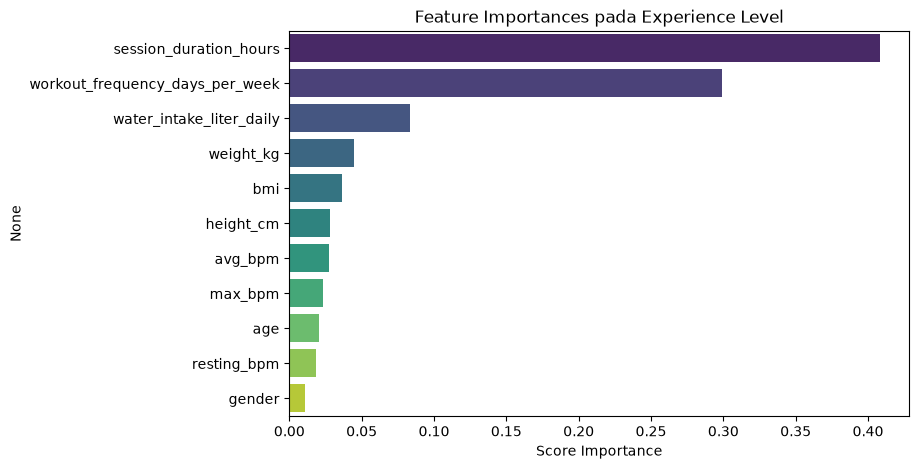

In [15]:
# Cek fitur mana yang paling menentukan tingkat kebugaran
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index, palette='viridis', legend=False)
plt.title('Feature Importances pada Experience Level')
plt.xlabel('Score Importance')
plt.show()

#### Step 8: Simpan Model Random Forest

In [16]:
joblib.dump(rf_model, 'random_forest_fitness_model.pkl')
print("Model Random Forest berhasil disimpan.")


Model Random Forest berhasil disimpan.


#### Step 9: Training Model Support Vector Machine (SVM) Classifier

In [17]:
# Inisialisasi SVC
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# Fitting Model menggunakan data terskala
svm_model.fit(X_train_scaled, y_train)
print("Model SVM berhasil dilatih!")

Model SVM berhasil dilatih!


#### Step 10: Evaluasi Model SVM (Akurasi & Confusion Matrix)

Akurasi Model SVM: 85.64%

--- Classification Report (SVM) ---
              precision    recall  f1-score   support

           1       0.81      0.83      0.82        75
           2       0.84      0.82      0.83        82
           3       1.00      1.00      1.00        38

    accuracy                           0.86       195
   macro avg       0.88      0.88      0.88       195
weighted avg       0.86      0.86      0.86       195



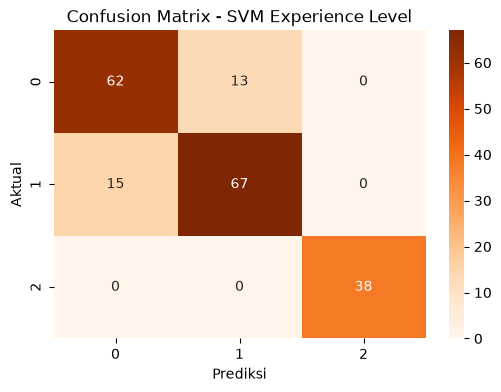

In [18]:
# Prediksi data test terskala
y_pred_svm = svm_model.predict(X_test_scaled)

# Hitung Akurasi
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Akurasi Model SVM: {acc_svm * 100:.2f}%")
print()

# Report Klasifikasi
print("--- Classification Report (SVM) ---")
print(classification_report(y_test, y_pred_svm))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVM Experience Level')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

#### Step 11: Simpan Model SVM

In [19]:
joblib.dump(svm_model, 'svm_fitness_model.pkl')
print("Model SVM berhasil disimpan.")

Model SVM berhasil disimpan.


#### Step 12: Training Model K-Nearest Neighbors (KNN) Classifier

In [20]:
# Inisialisasi KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Fitting Model menggunakan data terskala
knn_model.fit(X_train_scaled, y_train)
print("Model KNN berhasil dilatih!")

Model KNN berhasil dilatih!


#### Step 13: Evaluasi Model KNN (Akurasi & Confusion Matrix)

Akurasi Model KNN: 80.00%

--- Classification Report (KNN) ---
              precision    recall  f1-score   support

           1       0.77      0.79      0.78        75
           2       0.77      0.74      0.76        82
           3       0.92      0.95      0.94        38

    accuracy                           0.80       195
   macro avg       0.82      0.83      0.82       195
weighted avg       0.80      0.80      0.80       195



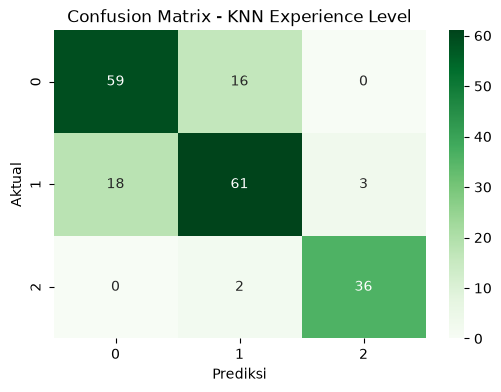

In [21]:
# Prediksi data test terskala
y_pred_knn = knn_model.predict(X_test_scaled)

# Hitung Akurasi
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi Model KNN: {acc_knn * 100:.2f}%")
print()

# Report Klasifikasi
print("--- Classification Report (KNN) ---")
print(classification_report(y_test, y_pred_knn))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN Experience Level')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

#### Step 14: Simpan Model KNN

In [22]:
joblib.dump(knn_model, 'knn_fitness_model.pkl')
print("Model KNN berhasil disimpan.")

Model KNN berhasil disimpan.


#### Step 15: Komparasi Performa Model (Random Forest vs SVM vs KNN)

=== Tabel Komparasi Akurasi ===
        Model  Accuracy (%)
Random Forest     90.256410
          SVM     85.641026
          KNN     80.000000


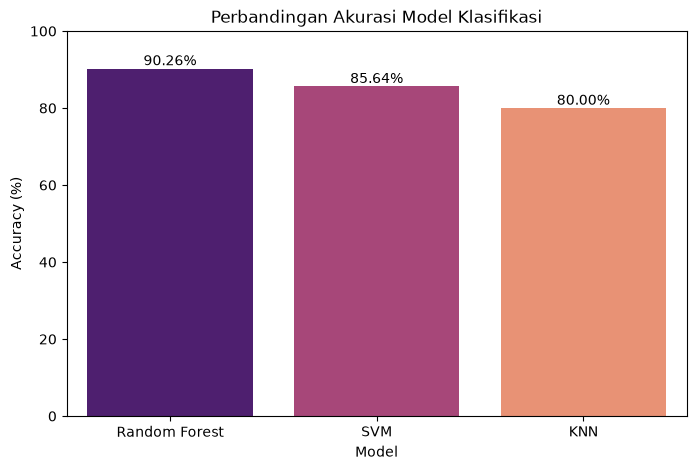

In [23]:
# DataFrame Komparasi Model
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy (%)': [acc * 100, acc_svm * 100, acc_knn * 100]
})

print("=== Tabel Komparasi Akurasi ===")
print(comparison_df.to_string(index=False))

# Visualisasi Komparasi Model
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Model', y='Accuracy (%)', data=comparison_df, hue='Model', palette='magma', legend=False)
plt.title('Perbandingan Akurasi Model Klasifikasi')
plt.ylim(0, 100)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()